# Data preprocessing

In order to develop a proper model for the estimation of the surface water fracture, we first must adapt the data of previous satelites so that they can be used in our model.

## Setup

### Library loading

Due to discrepancies between the rasterio and gdal libraries, we'll be using two different environments in this notebook.

#### General libraries

These are the necessary libraries to run most of the code.

In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import requests
import xarray as xr

from collections import defaultdict
from datetime import datetime, date, timedelta
from pathlib import Path
from scipy.ndimage import binary_dilation
from tqdm import tqdm
from typing import List

time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)

#### gdal library

The gdal library is necessary for the reprojection part of the notebook.

In [2]:
try:
    import os
    from osgeo import gdal, osr
except ImportError:
    # The osgeo/GDAL package is only required for the reprojection step (Section 3).
    # If it is not installed in the current environment, all other sections still work.
    print("Warning: osgeo/GDAL not available. Reprojection cell will not run.")

### Configuration & constants

The following cell centralises all tunable parameters and file paths used throughout the notebook. Modifying values here propagates automatically to every downstream cell.

In [3]:
# ── Spatial grid ──────────────────────────────────────────────────────────────
GRID_RES  = 0.25   # degrees – target resolution for LPDR reprojection
GRID_NLAT = 720    # 90°N to 90°S at 0.25°
GRID_NLON = 1440   # 180°W to 180°E at 0.25°

# ── Sensor parameters ─────────────────────────────────────────────────────────
VOD_RAW_MAX = 3.0  # Upper bound of raw LPDR VOD values (Neper); used for normalisation

# ── LUT bin edges (De Lannoy et al., 2016) ───────────────────────────────────
SM_BINS  = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
VOD_BINS = np.array([0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 1.0])

# ── Reference emissivity (De Lannoy et al., 2016, Table 2) ───────────────────
REF_WATER_EMISS_H = 0.288760  # Open-water emissivity at 18.7 GHz, H polarisation

# ── No-data sentinel ──────────────────────────────────────────────────────────
NODATA_VAL = -999.0

# ── File paths ────────────────────────────────────────────────────────────────
LPDR_RAW_DIR       = "data/lpdr/original"
LPDR_REP_DIR       = "data/lpdr/reprojected"
WINDSAT_DIR        = "data/windsat"
COMPLETE_DIR       = "data/complete"
LUT_H_PATH         = "data/lookup_tables/lut_de_lannoy_K_h.csv"
LUT_V_PATH         = "data/lookup_tables/lut_de_lannoy_K_v.csv"
LANDMASK_MAIN_PATH = "data/landmasks/GLWD_main_class_025deg.h5"
LANDMASK_PCT_PATH  = "data/landmasks/GLWD_all_classes_area_pct_025deg.h5"
DATASET_DIR        = "data/datasets"

## Data download

### LPDR data

The LPDR data can be downloaded from [NTSG's public data repository](http://files.ntsg.umt.edu). In order to automize the download, the following bash command can be used (adapted to the correct folder):

```
wget -w 0.5 -l 0 -r -nH -np \
  -I /data/LPDR_v3/GeoTif/2018/*,/data/LPDR_v3/GeoTif/2018 \
  -R "*.html,*.htm" \
  -P "/c/Users/marce/Documents/TFM_MCD_MarcVelascoMateu/data/LPDR/2017tif" \
  files.ntsg.umt.edu/data/LPDR_v3/GeoTif/2018
```

### WINDSAT data

The WINDSAT products are located in the [Remote Sensing Systems data repository](https://data.remss.com). Note that the download speed is excrutiengly long (around 7~15 minutes per file). It is recomended to download it in chuncks, progressively moving the `end_date` further away, or obtain the data in any other way.

In [4]:
BASE_URL = (
    "https://data.remss.com/TB/intercalibration/"
    "windsat_TB_maps_daily_025deg_unfiltered/"
)

OUTPUT_DIR = os.path.join("data", "WINDSAT")
os.makedirs(OUTPUT_DIR, exist_ok=True)

start_date = date(2017, 1, 1)
end_date = date(2018, 12, 31)

current_date = start_date

while current_date <= end_date:
    datestr = current_date.strftime("%Y_%m_%d")
    filename = f"RSS_WINDSAT_DAILY_TBTOA_MAPS_{datestr}.nc"
    url = BASE_URL + filename
    local_path = os.path.join(OUTPUT_DIR, filename)

    if os.path.exists(local_path):
        print(f"Skipping (already exists): {filename}")
        current_date += timedelta(days=1)
        continue

    print(f"Downloading: {filename}")

    try:
        response = requests.get(url, stream=True, timeout=60)
        response.raise_for_status()

        with open(local_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)

    except requests.RequestException as e:
        print(f"Failed to download {filename}: {e}")

    current_date += timedelta(days=1)

print("Download process completed.")

Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_01.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_02.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_03.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_04.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_05.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_06.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_07.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_08.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_09.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_10.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_11.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_12.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_13.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_14.nc
Skipping (already ex

In [5]:
# ── Download verification ────────────────────────────────────────────────────
# 1. Opens every .nc file to detect corruption
# 2. Reports any dates missing from the folder

_expected, _d = [], start_date
while _d <= end_date:
    _expected.append(_d)
    _d += timedelta(days=1)

corrupted, present = [], set()

for _d in _expected:
    _datestr = _d.strftime("%Y_%m_%d")
    _fname   = f"RSS_WINDSAT_DAILY_TBTOA_MAPS_{_datestr}.nc"
    _path    = os.path.join(OUTPUT_DIR, _fname)

    if os.path.exists(_path):
        try:
            ds = xr.open_dataset(_path, decode_times=time_coder)
            ds.close()
            present.add(_d)
        except Exception as e:
            print(f"CORRUPTED: {_fname}  →  {e}")
            corrupted.append(_fname)

missing = [_d for _d in _expected if _d not in present]

print(f"Files present : {len(present)}")
print(f"Corrupted     : {len(corrupted)}")
if corrupted:
    for f in corrupted:
        print(f"  - {f}")

print(f"\nMissing dates : {len(missing)}")
if missing:
    for _d in missing:
        print(f"  - {_d.strftime('%Y-%m-%d')}")
else:
    print("  None — all dates accounted for!")

Files present : 726
Corrupted     : 0

Missing dates : 4
  - 2017-08-09
  - 2017-08-10
  - 2017-08-11
  - 2018-11-04


## Sanity check and preliminary analysis

Now that we have all of our data, let's check it's structure and see if it's properly formated.

### LPDR

Let's check the current grid of these files

In [6]:
lpdr_ds = xr.open_dataset(f"{LPDR_RAW_DIR}/AMSRU_Mland_2017001A.tif", decode_times=time_coder)

print("Dimensions:", dict(lpdr_ds.sizes))
print("Coordinates:")
for coord in ["x", "y"]:
    if coord in lpdr_ds.coords:
        print(f"  {coord}: {lpdr_ds.coords[coord].values[0]}  →  {lpdr_ds.coords[coord].values[-1]}")

Dimensions: {'band': 7, 'x': 1383, 'y': 586}
Coordinates:
  x: -17321659.775000002  →  17321659.77499638
  y: 7332251.062494965  →  -7332251.0625035055


The LPDR dataset has an EASE-v2 projection.

We can also analyze the general structure of the dataset.

In [7]:
lpdr_ds

<xarray.Dataset> Size: 23MB
Dimensions:      (band: 7, x: 1383, y: 586)
Coordinates:
  * band         (band) int64 56B 1 2 3 4 5 6 7
  * x            (x) float64 11kB -1.732e+07 -1.73e+07 ... 1.73e+07 1.732e+07
  * y            (y) float64 5kB 7.332e+06 7.307e+06 ... -7.307e+06 -7.332e+06
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 23MB ...

Creating a codebook of these file will help us keep track of the different variables later on.

| Band | Band name | Parameter | Description                                                                 | Unit        | Valid range |
|------|-----------|-----------|------------------------------------------------------------------------------|-------------|-------------|
| 1    | fw        | —         | 30-day smoothed open water fraction                                          | Dimensionless | 0–1         |
| 2    | fwns      | —         | Non-smoothed open water fraction                                             | Dimensionless | 0–1         |
| 3    | Tmn / Tmx | —         | Daily surface air temperature minima or maxima, corresponding to descending or ascending pass retrievals | Kelvin      | 240–340     |
| 4    | PWV       | —         | Vertically integrated atmospheric water vapor                                | mm          | 0–80        |
| 5    | VOD       | —         | Vegetation optical depth at 10.7 GHz                                         | Neper       | 0–3         |
| 6    | vsm       | —         | Volumetric soil moisture at 10.7 GHz                                         | cm³/cm³     | 0–1         |
| 7    | VPD       | —         | Near-surface atmospheric vapor pressure deficit                              | kPa         | ≥ 0         |

### Windsat bands

Again, we'll observe the current grid.

In [8]:
windsat_ds = xr.open_dataset(f"{WINDSAT_DIR}/RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_01.nc", decode_times=time_coder)
windsat_ds = windsat_ds.set_coords(["longitude", "latitude"])

print("Dimensions:", dict(windsat_ds.sizes))
print("Coordinates:")
for coord in ["longitude", "latitude"]:
    if coord in windsat_ds.coords:
        print(f"  {coord}: {windsat_ds.coords[coord].values[0]}  →  {windsat_ds.coords[coord].values[-1]}")

Dimensions: {'longitude_grid': 1440, 'latitude_grid': 720, 'swath_sector': 2, 'look_direction': 2, 'frequency_band': 5, 'polarization': 4, 'polarization_dual': 2}
Coordinates:
  longitude: 0.125  →  359.875
  latitude: -89.875  →  89.875


The WINDSAT dataset has a simple EQR projection.

This dataset is quite large, so a preliminary analisis of its variables is near mandatory.

In [9]:
windsat_ds

<xarray.Dataset> Size: 1GB
Dimensions:         (longitude_grid: 1440, latitude_grid: 720, swath_sector: 2,
                     look_direction: 2, frequency_band: 5, polarization: 4,
                     polarization_dual: 2)
Coordinates:
    longitude       (longitude_grid) float32 6kB 0.125 0.375 ... 359.6 359.9
    latitude        (latitude_grid) float32 3kB -89.88 -89.62 ... 89.62 89.88
Dimensions without coordinates: longitude_grid, latitude_grid, swath_sector,
                                look_direction, frequency_band, polarization,
                                polarization_dual
Data variables: (12/32)
    node            (swath_sector) int32 8B ...
    look            (look_direction) int32 8B ...
    frequency_vpol  (frequency_band) float32 20B ...
    frequency_hpol  (frequency_band) float32 20B ...
    eia_nominal     (frequency_band) float32 20B ...
    time            (frequency_band, latitude_grid, longitude_grid, look_direction, swath_sector) object 166MB ...
    ...              ...
    colcld_WSAT     (latitude_grid, longitude_grid, swath_sector) float32 8MB ...
    rain_IMERG      (latitude_grid, longitude_grid, swath_sector) float32 8MB ...
    rain_WSAT       (latitude_grid, longitude_grid, swath_sector) float32 8MB ...
    tran            (polarization_dual, frequency_band, latitude_grid, longitude_grid, look_direction, swath_sector) float32 166MB ...
    tbup            (polarization_dual, frequency_band, latitude_grid, longitude_grid, look_direction, swath_sector) float32 166MB ...
    tbdw            (polarization_dual, frequency_band, latitude_grid, longitude_grid, look_direction, swath_sector) float32 166MB ...
Attributes: (12/71)
    Conventions:                            CF-1.7
    title:                                  RSS WindSat TOA Brightness Temper...
    version:                                V01.0
    summary:                                The dataset contains RSS WindSat ...
    references:                              [1] T. Meissner et al., Remote S...
    acknowledgement:                        Funded under NASA Grant 80NSSC21K...
    ...                                     ...
    Source_of_ancillary_NOAA_OI_SST:        NOAA OI SST V2 High Resolution Da...
    Source_of_ancillary_IMERG_rain_rate:    Huffman, G. et al.,  2019. NASA G...
    Source_of_ancillary_CCMP_wind:          Mears, C. et al., 2023.Remote Sen...
    Source_of_ancillary_HYCOM_SSS:          Hybrid Coordinate Ocean Model, GL...
    Source_of_ancillary_ERA5:               ECMWF Reanalysis v5 (ERA5). https...
    Source_of_RSS_WindSat_AS_ECV:           https://www.remss.com/missions/wi...

The following codebook collects the information provided in the summary.

| Variable         | Category           | Description                                    | Units             | Data Type | Notes                                      |
| ---------------- | ------------------ | ---------------------------------------------- | ----------------- | --------- | ------------------------------------------ |
| `longitude`      | Geolocation        | Geodetic longitude of observation              | degrees east      | float     | Range typically [-180, 180]                |
| `latitude`       | Geolocation        | Geodetic latitude of observation               | degrees north     | float     | Range [-90, 90]                            |
| `node`           | Orbit geometry     | Orbital node of satellite swath                | categorical / int | integer   | Ascending or descending orbit              |
| `look`           | Viewing geometry   | Look direction                                 | unitless          | integer   | 0 = fore, 1 = aft                          |
| `frequency_vpol` | Instrument         | Center frequency of V-polarization channel     | GHz               | float     | Per frequency band                         |
| `frequency_hpol` | Instrument         | Center frequency of H-polarization channel     | GHz               | float     | Per frequency band                         |
| `eia_nominal`    | Viewing geometry   | Nominal Earth incidence angle                  | degrees           | float     | Per frequency band                         |
| `time`           | Temporal           | Time of observation                            | seconds           | float     | Seconds since 2000-01-01 00:00:00 UTC      |
| `eaa`            | Viewing geometry   | Boresight Earth azimuth angle                  | degrees           | float     | Range [0, 360]                             |
| `eia`            | Viewing geometry   | Boresight Earth incidence angle                | degrees           | float     | Range [0, 90]                              |
| `tbtoa`          | Radiometry         | Top-of-atmosphere brightness temperature       | Kelvin (K)        | float     | Observed microwave brightness temperature  |
| `quality_flag`   | Quality control    | Quality control bitmask                        | unitless          | uint32    | 32-bit encoded quality and screening flags |
| `sss_HYCOM`      | Ocean (HYCOM)      | Sea surface salinity from HYCOM                | PSU               | float     | Model-derived                              |
| `surtep_REY`     | Ocean (Reynolds)   | Sea surface temperature (NOAA Reynolds V2 OI)  | Kelvin (K)        | float     | Daily gridded OI SST                       |
| `fland_06`       | Surface            | Land fraction at 6 GHz                         | unitless          | float     | Fractional land contamination              |
| `fland_10`       | Surface            | Land fraction at 10 GHz                        | unitless          | float     | Fractional land contamination              |
| `surtep_WSAT`    | Windsat            | Skin temperature                               | Kelvin (K)        | float     | Windsat V8 product                         |
| `colvap_WSAT`    | Windsat            | Column-integrated water vapor                  | kg m⁻²            | float     | Windsat V8 product                         |
| `colcld_WSAT`    | Windsat            | Column-integrated cloud liquid water           | kg m⁻²            | float     | Windsat V8 product                         |
| `winspd_WSAT`    | Windsat            | Sea surface wind speed                         | m s⁻¹             | float     | Windsat V8 product                         |
| `rain_WSAT`      | Windsat            | Surface rain rate                              | mm hr⁻¹           | float     | Windsat V8 product                         |
| `winspd_CCMP`    | CCMP               | Sea surface wind speed                         | m s⁻¹             | float     | Cross-Calibrated Multi-Platform product    |
| `windir_CCMP`    | CCMP               | Sea surface wind direction                     | degrees           | float     | Meteorological convention                  |
| `surtep_ERA5`    | ERA5               | Surface (skin) temperature                     | Kelvin (K)        | float     | ERA5 reanalysis                            |
| `airtep_ERA5`    | ERA5               | 2 m air temperature                            | Kelvin (K)        | float     | ERA5 near-surface air temperature          |
| `colvap_ERA5`    | ERA5               | Column-integrated water vapor                  | kg m⁻²            | float     | ERA5 reanalysis                            |
| `colcld_ERA5`    | ERA5               | Column-integrated cloud liquid water           | kg m⁻²            | float     | ERA5 reanalysis                            |
| `winspd_ERA5`    | ERA5               | 10 m neutral-stability wind speed              | m s⁻¹             | float     | ERA5 reanalysis                            |
| `windir_ERA5`    | ERA5               | 10 m wind direction                            | degrees           | float     | ERA5 reanalysis                            |
| `surtep_CMC`     | CMC                | Sea surface temperature                        | Kelvin (K)        | float     | Canadian Meteorological Centre SST         |
| `rain_IMERG`     | IMERG              | Surface rain rate                              | mm hr⁻¹           | float     | IMERG V6 precipitation product             |
| `tran`           | Radiative transfer | Total atmospheric transmittance                | unitless          | float     | Dual-polarization dimension                |
| `tbdw`           | Radiative transfer | Atmospheric downwelling brightness temperature | Kelvin (K)        | float     | Dual-polarization dimension                |
| `tbup`           | Radiative transfer | Atmospheric upwelling brightness temperature   | Kelvin (K)        | float     | Dual-polarization dimension                |

## Reprojection

LPDR files use the **EASE-Grid v1** projection (EPSG:3410 – cylindrical equal-area), while WINDSAT data is stored on a standard **geographic / equidistant cylindrical** grid (EPSG:4326) at 0.25° resolution.

To allow pixel-level merging of the two datasets, the LPDR files must be reprojected onto the same 0.25° geographic grid. The function below uses GDAL to warp each LPDR GeoTIFF from EPSG:3410 to EPSG:4326 at the target 1440 × 720 grid, using nearest-neighbour resampling (which preserves integer class values) and a −999 no-data sentinel.

In [ ]:
def reproject_file(file_path: str, output_folder: str = None) -> bool:
    """
        Read the input geotiff in EASE v1
        Reproject + resample into ED 0.25º
        create latitude an longitude bands for convenience.
        (bands added as second to last, and last band respectively)

        param output_folder: name of the new file to save reprojected data.
            If None, data will be ovewritten in file_path.

        Returns bool: whether or not the file was succesfully reprojected
    """
    dataset = gdal.Open(file_path)

    # Define the geotransform for the output dataset
    target_geotransform = (0, 0.25, 0.0, 90.0, 0.0, -0.25)

    output_width = 1440
    output_height = 720

    # Define src and geotransform from the input:
    source_srs = osr.SpatialReference()
    source_srs.ImportFromEPSG(3410)

    # Desired projection
    target_srs = osr.SpatialReference()
    target_srs.ImportFromEPSG(4326)

    # Declare the output file and driver:
    driver = gdal.GetDriverByName("GTiff")

    if output_folder is None:
        output_file = os.path.join(os.path.dirname(file_path), "temp.tif")

    else:
        output_file = os.path.join(output_folder, os.path.basename(file_path))

    # Create the new dataset
    output_dataset = driver.Create(
        output_file, output_width, output_height,
        dataset.RasterCount,
        gdal.GDT_Float32
    )
    output_dataset.SetProjection(target_srs.ExportToWkt())
    output_dataset.SetGeoTransform(target_geotransform)

    # Set the output dataset value to -999.0, instead of 0.
    for i in range(1, output_dataset.RasterCount, 1):
        band = output_dataset.GetRasterBand(i)
        arr = band.ReadAsArray()
        arr = arr - 999.0
        band.WriteArray(arr)

    # Reproject and resample using gdal.Warp()
    gdal.Warp(
        output_dataset,
        dataset,
        dstSRS=target_srs.ExportToWkt(),
        width=output_width,
        height=output_height,
        resampleAlg="near",
        # GRA_Bilinear TODO: bilinear warp does not work with Nodata params,
        # there will be values between -999 and the valid range
        srcNodata=float(-999.0),
        dstNodata=-999.0,
    )

    # Close the files
    dataset = None
    output_dataset = None

    if output_folder is None:
        # Delete original file, rename temp file.
        os.remove(file_path)
        os.rename(output_file, file_path)

    return True

print('START')

# NOTE: Do not reproject Quality Flag files for now,
# those files end in '\d{3}QA.tif'
# Select only ascending and descending passes:
regex = r"\d{7}[AD].tif"

for file_name in os.listdir(LPDR_RAW_DIR):
    file_path = os.path.join(LPDR_RAW_DIR, file_name)
    print(f"Reprojecting {file_path}")

    outcome = reproject_file(file_path, output_folder=LPDR_REP_DIR)

    if outcome:
        print("Reprojected")
        if LPDR_REP_DIR is not None:
            print(
                f"""New file saved {
                    os.path.join(LPDR_REP_DIR, file_name)
                }"""
            )
    else:
        print(f"File {file_name} is already reprojected")

print("DONE")

Let's check the new files to see if the reprojection worked accordingly.

In [11]:
lpdr_rep_ds = xr.open_dataset(f'{LPDR_REP_DIR}/AMSRU_Mland_2017001A.tif')

lpdr_rep_ds = lpdr_rep_ds.rename({
    "x": "longitude",
    "y": "latitude"
})
lpdr_rep_ds = lpdr_rep_ds.sortby("latitude")

print("Dimensions:", dict(lpdr_rep_ds.sizes))
print("Coordinates:")
for coord in ["longitude", "latitude"]:
    if coord in lpdr_rep_ds.coords:
        print(f"  {coord}: {lpdr_rep_ds.coords[coord].values[0]}  →  {lpdr_rep_ds.coords[coord].values[-1]}")

Dimensions: {'band': 7, 'longitude': 1440, 'latitude': 720}
Coordinates:
  longitude: 0.125  →  359.875
  latitude: -89.875  →  89.875


As we can see, the reprojection worked perfectly, and we can move on to the next step.

## Harmonization

Since all datasets now follow the same grid, we can go ahead and combine all three of them into a single training dataset. However, if we were to combine all files without previous pruning, we'll end up with unmanageble datasets. For this reason, we'll first select only the necessary data for our research.

This is the data we'll keep of every type.

**LPDR**

* Direction: Descending

* Variables: All of them but fw

**WINDSAT**

* Direction: Descending (1)

* Frequencies: 18.7 (0 Ku) and 37.0 (1 Ka)

* Polarizations: V (0) and H (1)

* Look direction: Fore (0)

* Variables: tbtoa, tbup, tbdw, tran, surtep_ERA5

Before mixing all of the datasets, let's start by preprocessing a single day as an example.

In [12]:
VARIABLES = {
    2: 'fwns',
    3: 'Tmn',
    4: 'PWV',
    5: 'VOD',
    6: 'vsm',
    7: 'VPD',
}

WINDSAT_VARS = [
    'tbtoa',
    'tran',
    'tbdw',
    'tbup',
    'surtep_ERA5'
]

def extract_amsru_variables(ds, band_names):
    lpdr_vars = {}

    for band, name in band_names.items():
        lpdr_vars[name] = (
            ds.band_data
            .sel(band=band)
            .drop_vars(['band', 'spatial_ref'])
        )

    return xr.Dataset(lpdr_vars)

def reduce_windsat_dataset(ds):
    # Subset using actual dimension names
    ds = ds.isel(
        swath_sector=1,             # Descending
        look_direction=0,           # Fore
        frequency_band=[0, 1],      # 18.7 & 37 GHz
        polarization=[0, 1],        # V/H
    )
    return ds[WINDSAT_VARS]

def atmospheric_corrections(ds: xr.Dataset) -> xr.Dataset:
    """
    Apply atmospheric correction to the brightness temperatures.

    Two formulas are implemented:

    **1st-order approximation**
        TBBoA = (TBToA - TBau) / tau
        where tau is the atmospheric transmittance and TBau is the upwelling
        atmospheric brightness temperature.

    **De Lannoy (2016) two-stream formula**
        TBBoA = Ts * [(TBToA / tau) - (1 + 1/tau) * TBau] / (Ts - TBau)
        where Ts is the ERA5 land surface skin temperature.

    Returns the same dataset with two new variables:
        - tbboa_1st_order
        - tbboa_de_lannoy
    """
    ds["tbboa_1st_order"] = (ds.tbtoa - ds.tbup) / ds.tran
    ds["tbboa_de_lannoy"] = (
        ds.surtep_ERA5
        * ((ds.tbtoa * (1 / ds.tran)) - ds.tbup * (1 + (1 / ds.tran)))
        / (ds.surtep_ERA5 - ds.tbup)
    )
    return ds

def load_lut(ds: xr.Dataset, lut_filepath: str,) -> xr.Dataset:
    """
    Read a lookup table CSV and attach the corresponding reference land
    emissivity to every pixel based on its soil-moisture and VOD bin.

    The LUT is indexed by (sm_bin, vod_bin) following De Lannoy et al. (2016).
    Bin edges are defined in SM_BINS and VOD_BINS in the configuration cell.

    Parameters
    ----------
    ds           : merged dataset containing 'vsm' and 'VOD' variables
    lut_filepath : path to the polarisation-specific CSV lookup table

    Returns
    -------
    ds with an added 'ref_land_emis_<pol>' variable
    (e.g. ref_land_emis_de_lannoy_K_h)
    """

    sm_bins  = SM_BINS
    vod_bins = VOD_BINS

    sm_slices  = [(sm_bins[i],  sm_bins[i+1])  for i in range(len(sm_bins)  - 1)]
    vod_slices = [(vod_bins[i], vod_bins[i+1]) for i in range(len(vod_bins) - 1)]

    # Recreate the bin indices used when generating the LUTs
    sm_idx  = np.full(ds.vsm.shape, np.nan)
    vod_idx = np.full(ds.VOD.shape, np.nan)

    for i, (sm_min, sm_max) in enumerate(sm_slices):
        sm_idx[(ds.vsm >= sm_min) & (ds.vsm < sm_max)] = i

    for j, (vod_min, vod_max) in enumerate(vod_slices):
        vod_idx[(ds.VOD >= vod_min) & (ds.VOD < vod_max)] = j

    sm_idx  = xr.DataArray(sm_idx,  dims=ds.vsm.dims)
    vod_idx = xr.DataArray(vod_idx, dims=ds.VOD.dims)

    # Assign bin indices as coordinates
    ds = ds.assign_coords(sm_bin=sm_idx, vod_bin=vod_idx)

    # Load LUT from CSV
    lut_df = pd.read_csv(lut_filepath, index_col=0)
    lut_xr = xr.DataArray(lut_df)

    # Replace NaN bins with -1 sentinel (required for integer indexing)
    ds["sm_bin"]  = ds["sm_bin"].fillna(-1).astype(int)
    ds["vod_bin"] = ds["vod_bin"].fillna(-1).astype(int)

    # Derive polarisation name from filename (e.g. "de_lannoy_K_h")
    pol_name = os.path.basename(lut_filepath).removeprefix("lut_").removesuffix(".csv")

    ds[pol_name] = (("sm_bin", "vod_bin"), lut_xr.values)

    # Map each pixel to its LUT reference emissivity value
    dvar_name = "ref_land_emis_" + pol_name
    ds[dvar_name] = ds[pol_name].sel(sm_bin=ds["sm_bin"], vod_bin=ds["vod_bin"]).astype(np.float32)

    # Drop the LUT matrix variable and its temporary sm_bin/vod_bin dimensions
    ds = ds.drop_dims(["sm_bin", "vod_bin"])

    # Nullify pixels where BOTH SM and VOD were outside the LUT valid range
    # (both bins set to -1 sentinel), matching the reference implementation.
    missing_vodsm = (ds.sm_bin == -1) & (ds.vod_bin == -1)
    ds = ds.where(~missing_vodsm)

    return ds

def unravel_freqpol(ds: xr.Dataset, dvars: list[str]) -> xr.Dataset:
    """
    FROM LST ATBD
    Unravel the frequency and polarization dimensions into
    a set of new data variables, for each dvar in list.
    Returns the dataset with added fields.
    """
    frequencies = {
        0: "19",
        1: "37",
    }
    polarizations = {
        0: "V",
        1: "H",
    }

    for dvar in dvars:

        if dvar not in ds.data_vars:
            print(f"Warning: {dvar} not found in dataset.")
            continue

        for freqid, freqname in frequencies.items():
            for polid, polname in polarizations.items():
                new_name = f"{dvar}{freqname}{polname}"
                ds[new_name] = ds[dvar].isel(
                    polarization=polid, frequency_band=freqid
                )

    return ds

# -- High-level preprocessing helpers -------------------------------------
def preprocess_lpdr(file_path: str) -> xr.Dataset:
    """
    Load and preprocess a single LPDR (AMSRU) reprojected GeoTIFF file.

    Steps:
    1. Load the GeoTIFF as an xarray Dataset.
    2. Rename spatial coordinates (x -> longitude_grid, y -> latitude_grid).
    3. Extract target variables from the band_data array using VARIABLES.
    4. Flip and sort latitude (EASE grid stores rows N->S; we want S->N).
    5. Normalise VOD from raw Neper range [0, VOD_RAW_MAX] to [0, 1].
    """
    ds = xr.open_dataset(file_path)
    ds = ds.rename({"x": "longitude_grid", "y": "latitude_grid"})
    ds = extract_amsru_variables(ds, VARIABLES)
    ds = ds.assign_coords(
        latitude_grid=-ds.latitude_grid[::-1].astype('float32')
    )
    ds = ds.sortby("latitude_grid")
    old_attrs = ds.VOD.attrs
    ds["VOD"] = ds.VOD / VOD_RAW_MAX
    old_attrs.update({
        "Valid_range": "0-1",
        "Description": f"NORMALIZED VOD, original is 0-{VOD_RAW_MAX} Neper"
    })
    ds.VOD.attrs = old_attrs
    return ds

def preprocess_lpdr_quality_flag(file_path: str) -> xr.Dataset:
    """
    Load and preprocess a single LPDR (AMSRU) reprojected GeoTIFF file.

    Steps:
    1. Load the GeoTIFF as an xarray Dataset.
    2. Rename spatial coordinates (x -> longitude_grid, y -> latitude_grid).
    3. Flip and sort latitude (EASE grid stores rows N->S; we want S->N).
    """
    ds = xr.open_dataset(file_path)
    ds = ds.rename({"x": "longitude_grid", "y": "latitude_grid"})
    lpdr_vars = {}
    lpdr_vars['quality_flag'] = ds.band_data.sel(band=1).drop_vars(['band', 'spatial_ref'])
    ds = xr.Dataset(lpdr_vars)
    ds = ds.assign_coords(
        latitude_grid=-ds.latitude_grid[::-1].astype('float32')
    )
    ds = ds.sortby("latitude_grid")
    return ds

def preprocess_windsat(file_path: str) -> xr.Dataset:
    """
    Load and preprocess a single WINDSAT daily NetCDF file.

    Steps:
    1. Load the NetCDF with CF-time decoding.
    2. Create longitude_grid / latitude_grid coordinate aliases.
    3. Subset to descending fore swath, 18.7 & 37 GHz, V & H polarisations.
    4. Rename polarization_dual -> polarization.
    5. Apply atmospheric corrections (1st-order and De Lannoy 2016).
    """
    ds = xr.open_dataset(file_path, decode_times=time_coder)
    ds = ds.assign_coords(
        longitude_grid=ds.longitude,
        latitude_grid=ds.latitude,
    )
    ds.latitude_grid.attrs["long_name"] = "latitude_grid"
    ds.longitude_grid.attrs["long_name"] = "longitude_grid"
    ds.latitude_grid.attrs["units"] = "degN"
    ds.longitude_grid.attrs["units"] = "degE"
    ds = reduce_windsat_dataset(ds)
    ds = ds.rename({'polarization_dual': 'polarization'})
    ds = atmospheric_corrections(ds)
    return ds

def load_landmask(main_class_path: str = None, pct_class_path: str = None,) -> tuple:
    """
    Load and prepare the two GLWD landmask datasets.

    Returns a (lm, lm_pct) tuple ready to be passed to apply_landmask().
    Loading is separated from merging so the datasets can be reused across
    all daily iterations without re-reading the files each time.
    """
    if main_class_path is None:
        main_class_path = LANDMASK_MAIN_PATH
    if pct_class_path is None:
        pct_class_path = LANDMASK_PCT_PATH

    lm     = xr.open_dataset(main_class_path, decode_times=time_coder)
    lm_pct = xr.open_dataset(pct_class_path,  decode_times=time_coder)

    for mask in [lm, lm_pct]:
        mask.latitude_grid.attrs["long_name"]  = "latitude_grid"
        mask.longitude_grid.attrs["long_name"] = "longitude_grid"
        mask.latitude_grid.attrs["units"]  = "degN"
        mask.longitude_grid.attrs["units"] = "degE"

    lm     = lm.sortby("latitude_grid")
    lm_pct = lm_pct.sortby("latitude_grid")
    return lm, lm_pct

def apply_landmask(ds: xr.Dataset, lm: xr.Dataset, lm_pct: xr.Dataset,) -> xr.Dataset:
    """
    Integrate the GLWD landmask into ds and add a 'coastal' class.

    The coastal class is identified via binary dilation: any land pixel
    adjacent (8-connectivity) to at least one sea pixel receives a new
    class value of max(existing_classes) + 1. This lets the model treat
    coastal pixels separately from open land and open ocean.

    Parameters
    ----------
    ds    : dataset to merge the landmask into
    lm    : GLWD main-class dataset (output of load_landmask)
    lm_pct: GLWD percentage-area dataset (output of load_landmask)

    Returns
    -------
    ds with 'clase' and all percentage-area variables merged in
    """
    da       = lm['clase']
    land     = ~np.isnan(da)
    sea      = np.isnan(da)
    sea_near = binary_dilation(sea, structure=np.ones((3, 3)))
    coastal  = land & sea_near
    new_class = int(np.nanmax(da.values)) + 1

    lm_with_coast = lm.copy(deep=True)
    lm_with_coast['clase'].values[coastal] = new_class

    ds = xr.merge([ds, lm_with_coast], join="exact")
    ds = xr.merge([ds, lm_pct],        join="exact")
    ds["clase"] = ds["clase"].astype(np.float32)
    ds["porcentaje clase"] = ds["porcentaje clase"].astype(np.float32)
    return ds

### LPDR preprocessing

The LPDR file is loaded from the reprojected folder (EPSG:4326, 0.25°). Key steps:

1. **Coordinate rename**: the GeoTIFF axes `x`/`y` are renamed to `longitude_grid`/`latitude_grid` for consistency with WINDSAT.
2. **Variable extraction**: seven variables are pulled from the multi-band `band_data` array using the `VARIABLES` codebook defined above.
3. **Latitude flip**: EASE-grid rows run north-to-south; after reprojection the latitude values must be negated and then sorted to obtain a south-to-north (ascending) order.
4. **VOD normalisation**: raw VOD values span `[0, VOD_RAW_MAX]` Neper and are linearly rescaled to `[0, 1]` for consistency with the LUT bin edges.

The `preprocess_lpdr` helper encapsulates all of these steps.

In [13]:
# Load and preprocess a single day of LPDR data (descending pass)
lpdr_ds_reduced = preprocess_lpdr(f'{LPDR_REP_DIR}/AMSRU_Mland_2017001D.tif')

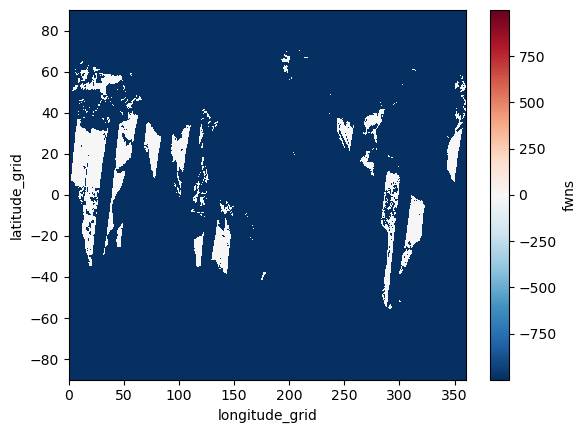

In [14]:
# Check for sanity
lpdr_ds_reduced['fwns'].plot()
plt.show()

### WINDSAT preprocessing

The WINDSAT file is already in EPSG:4326, so no reprojection is needed. Key steps:

1. **Coordinate aliases**: `longitude` and `latitude` are aliased to `longitude_grid`/`latitude_grid` to match the LPDR naming convention.
2. **Subsetting**: only the descending swath (`swath_sector=1`), fore-look direction, 18.7 GHz and 37 GHz bands, and V/H polarisations are retained (see *Data conciliation* for the rationale).
3. **Atmospheric corrections**: two corrected brightness-temperature fields are added:
   - `tbboa_1st_order` – simple single-layer approximation
   - `tbboa_de_lannoy` – two-stream formula from De Lannoy et al. (2016)

The `preprocess_windsat` helper encapsulates all of these steps.

In [15]:
# Load and preprocess a single day of WINDSAT data
windsat_ds_augmented = preprocess_windsat(f'{WINDSAT_DIR}/RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_01.nc')

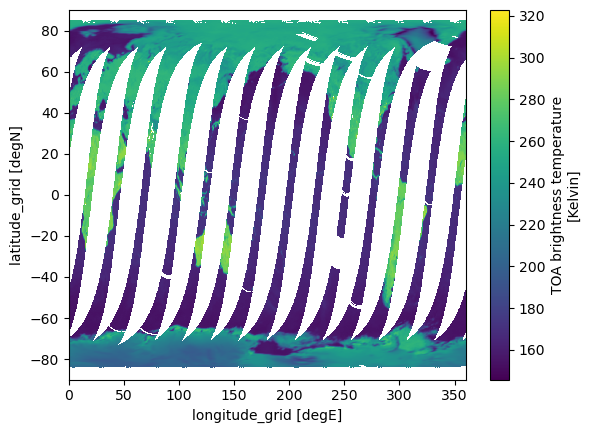

In [16]:
# Check for sanity
windsat_ds_augmented['tbtoa'].sel(polarization=0, frequency_band=0).plot()
plt.show()

### Conjoined preprocessing

Both preprocessed datasets share an identical 0.25° geographic grid, so they can be merged pixel-by-pixel using `join="exact"`.

In [17]:
# Merge the datasets
# join="exact" requires both datasets to share identical coordinate values.
# This is guaranteed because both have been reprojected to the same 0.25° global grid.
merged_ds = xr.merge([windsat_ds_augmented, lpdr_ds_reduced], join="exact")

In [18]:
merged_ds_augmented = merged_ds.copy()
merged_ds_augmented = load_lut(merged_ds_augmented, lut_filepath=LUT_H_PATH)
merged_ds_augmented = load_lut(merged_ds_augmented, lut_filepath=LUT_V_PATH)

# Unravel tbtoa and correction terms into individual frequency/polarisation arrays
# e.g. tbtoa → tbtoa19H, tbtoa19V, tbtoa37H, tbtoa37V
merged_ds_augmented = unravel_freqpol(merged_ds_augmented, dvars=['tbtoa', 'tran', 'tbdw', 'tbup', 'tbboa_1st_order', 'tbboa_de_lannoy'])
merged_ds_augmented = merged_ds_augmented.drop_vars(['tbtoa', 'tran', 'tbdw', 'tbup', 'tbboa_1st_order', 'tbboa_de_lannoy'])

# Cast unraveled vars to float32
_unraveled = [
    f"{v}{f}{p}"
    for v in ['tbtoa', 'tran', 'tbdw', 'tbup', 'tbboa_1st_order', 'tbboa_de_lannoy']
    for f in ['19', '37'] for p in ['H', 'V']
]
for _var in _unraveled:
    merged_ds_augmented[_var] = merged_ds_augmented[_var].astype(np.float32)

# Compute de-Lannoy emissivity: e = TBBoA / Ts  (Ts = ERA5 skin temperature)
for freq in ["19", "37"]:
    for pol in ["H", "V"]:
        merged_ds_augmented[f"emiss{freq}{pol}_de_lannoy"] = (merged_ds_augmented[f"tbboa_de_lannoy{freq}{pol}"] / merged_ds_augmented["surtep_ERA5"]).astype(np.float32)

# Surface Water Fraction (SWF) calculation (De Lannoy et al., 2016):
#
#   fwns = (e_land_H - e_obs_H) / (e_land_H - e_water_H)
#
# where:
#   e_land_H/V  = LUT reference land emissivity at 18.7 GHz H/V
#   e_obs_H     = observed emissivity (tbboa_de_lannoy / Ts) at 18.7 GHz H
#   e_water_H   = REF_WATER_EMISS_H (open-water emissivity, De Lannoy 2016 Table 2)
merged_ds_augmented["denominator"] = (1 / (merged_ds_augmented.ref_land_emis_de_lannoy_K_h - REF_WATER_EMISS_H)).astype(np.float32)
merged_ds_augmented["term_1"] = (merged_ds_augmented.ref_land_emis_de_lannoy_K_h / (merged_ds_augmented.ref_land_emis_de_lannoy_K_h - REF_WATER_EMISS_H)).astype(np.float32)
merged_ds_augmented["term_2"] = (merged_ds_augmented.emiss19H_de_lannoy / (merged_ds_augmented.ref_land_emis_de_lannoy_K_h - REF_WATER_EMISS_H)).astype(np.float32)
merged_ds_augmented["fwns_calculated"] = ((merged_ds_augmented.ref_land_emis_de_lannoy_K_h - merged_ds_augmented.emiss19H_de_lannoy) / (merged_ds_augmented.ref_land_emis_de_lannoy_K_h - REF_WATER_EMISS_H)).astype(np.float32)

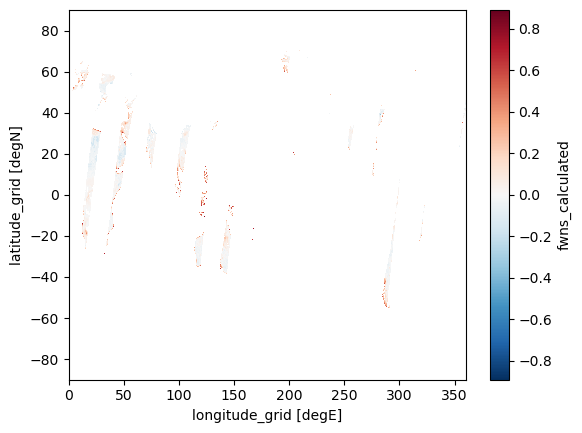

In [19]:
# Check for sanity
merged_ds_augmented['fwns_calculated'].plot()
plt.show()

### Adding landmask

The [Global Lakes and Wetlands Database (GLWD)](https://www.worldwildlife.org/pages/global-lakes-and-wetlands-database) provides a 0.25° land-cover classification (`clase`) and fractional area estimates for each class. Two extra steps are applied before merging:

1. **Coastal class**: pixels on the land–sea boundary are flagged with a new class (`max_class + 1`) using 8-connected binary dilation of the sea mask. This lets the model treat coastal mixing separately from open land and open ocean.
2. **Exact merge**: both landmask datasets share the same 0.25° grid as the satellite data, so a direct `join="exact"` merge is safe.

`load_landmask()` loads and sorts the files; `apply_landmask()` performs the dilation and merging. Both functions are defined in the *Data conciliation* section.

In [20]:
# Load the GLWD landmask datasets once (reused here and in the main loop)
lm, lm_pct = load_landmask()

# Merge the landmask into the augmented dataset.
# Coastal pixels (land touching sea) are assigned a separate class via binary dilation.
merged_ds_final = apply_landmask(merged_ds_augmented, lm, lm_pct)

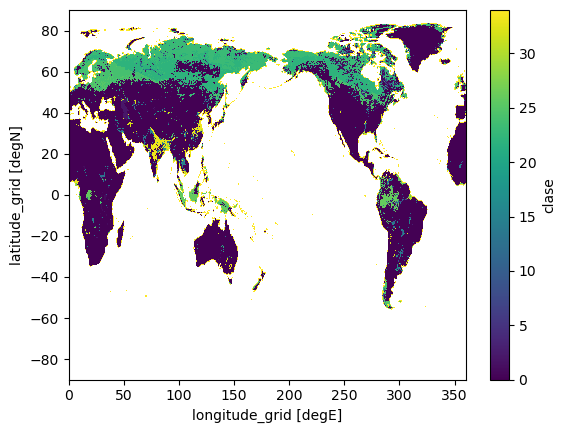

In [21]:
# Check for sanity
merged_ds_final['clase'].plot()
plt.show()

### Final masking

Three validity filters are applied to remove pixels that carry no useful information for model training:

| Filter | Condition | Reason |
|--------|-----------|--------|
| No-class | `clase` is not null | Removes open-ocean pixels that have no land classification |
| Valid VSM | `vsm > -995` | Removes LPDR no-data sentinel values for volumetric soil moisture |
| Valid FWNS | `fwns > -995` | Removes LPDR no-data sentinel values for surface water fraction |

In [22]:
# Filter data to save space and standardize the dataset
merged_ds_final = merged_ds_final.where(~merged_ds_final.clase.isnull())
merged_ds_final = merged_ds_final.where(merged_ds_final.clase!=34)
merged_ds_final = merged_ds_final.where(merged_ds_final['vsm']>-995)
merged_ds_final = merged_ds_final.where(~merged_ds_final.tbboa_de_lannoy19H.isnull())

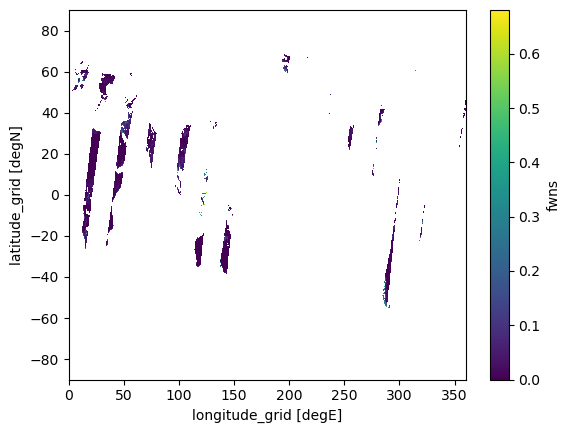

In [23]:
# Check for sanity
merged_ds_final['fwns'].plot()
plt.show()

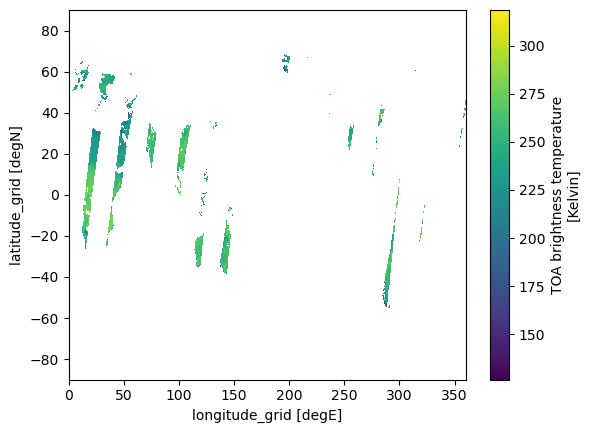

In [24]:
# Check for sanity
merged_ds_final['tbtoa19H'].plot()
plt.show()

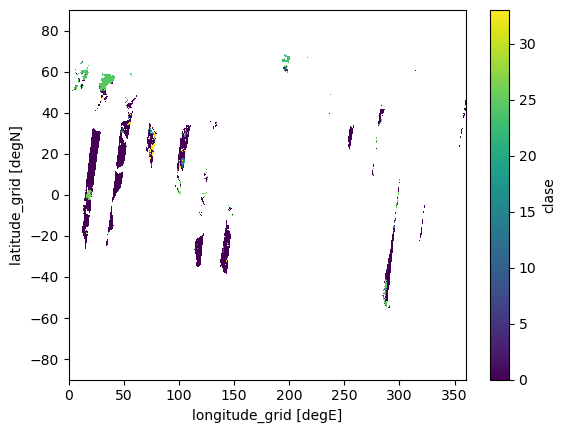

In [25]:
# Check for sanity
merged_ds_final['clase'].plot()
plt.show()

### File pairing

Before merging the full year of data, each LPDR file must be paired with the WINDSAT file that covers the same calendar day.

**Why only descending passes?**
The descending LPDR pass corresponds to the local morning overpass (~6 AM local time). At this time soil thermal conditions are more stable and closer to the ERA5 skin temperature used in the atmospheric correction, which improves consistency with the WINDSAT observation geometry.

Quality-flag files (ending in `QA.tif`) and ascending passes (`A.tif`) are therefore excluded; only descending (`D.tif`) files are retained.

In [26]:
def get_year_and_doy(file_path):
    file_path = str(file_path)
    if 'AMSRU' in file_path:
        year_doy_str = os.path.basename(file_path).split('_')[2][:7]
        year = year_doy_str[:4]
        doy  = year_doy_str[4:]
    elif 'WINDSAT' in file_path:
        year, month, day = os.path.basename(file_path).split("_")[-3:]
        day = day.replace(".nc", "")
        date = datetime(int(year), int(month), int(day))
        year = str(year)
        doy  = f"{date.timetuple().tm_yday:03d}"
    return year, doy

def group_files_by_day(lpdr_dir: str, windsat_dir: str) -> List[List[str]]:
    # (year, doy) -> {"lpdr": ..., "qa": ..., "windsat": ...}
    grouped = defaultdict(lambda: {"lpdr": [], "qa": [], "windsat": []})

    # Collect LPDR files — descending pass only (D.tif), excluding QA files
    for path in Path(lpdr_dir).iterdir():
        if path.is_file():
            if path.stem.endswith("D_QA"):
                key = get_year_and_doy(path)
                grouped[key]["qa"].append(str(path))
            elif path.stem.endswith("D"):
                key = get_year_and_doy(path)
                grouped[key]["lpdr"].append(str(path))

    # Collect WINDSAT files
    for path in Path(windsat_dir).iterdir():
        if path.is_file():
            key = get_year_and_doy(path)
            grouped[key]["windsat"].append(str(path))

    # Build final list, sorted by (year, doy)
    output = []
    for key in sorted(grouped.keys()):
        year, doy = key
        lpdr_files    = sorted(grouped[key]["lpdr"])
        qa_files      = sorted(grouped[key]["qa"])
        windsat_files = sorted(grouped[key]["windsat"])

        # Sanity checks
        if len(lpdr_files) > 4:
            raise ValueError(f"More than 4 LPDR-D files for year {year} DOY {doy}")
        if len(qa_files) > 1:
            raise ValueError(f"More than 1 QA file for year {year} DOY {doy}")
        if len(windsat_files) > 1:
            raise ValueError(f"More than 1 WINDSAT file for year {year} DOY {doy}")

        # Pair only when both a WINDSAT file and a QA file exist
        if windsat_files and qa_files:
            output.append(lpdr_files + qa_files + windsat_files)

    return output

In [27]:
corresponding_files = group_files_by_day(LPDR_REP_DIR, WINDSAT_DIR)

### Dataset unification

This section runs the full preprocessing pipeline on every paired day and saves one merged NetCDF per day.

For each day the pipeline:
1. Loads and preprocesses the descending LPDR file via `preprocess_lpdr`.
2. Loads and preprocesses the WINDSAT file via `preprocess_windsat`.
3. Merges both datasets on the shared 0.25° grid.
4. Applies the H and V lookup tables and unravels all frequency/polarisation dimensions.
5. Computes surface emissivity and the Surface Water Fraction estimate.
6. Merges the GLWD landmask (loaded **once** outside the loop for efficiency).
7. Writes the result to a NetCDF file.

In [29]:
output_dir = Path(COMPLETE_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

# Load the landmask once outside the loop to avoid redundant file I/O for each day
lm, lm_pct = load_landmask()

for files in tqdm(corresponding_files, desc="Processing days", unit="day"):
    # --- File names ---
    lpdr_D_data, qa_file, windsat_file = files

    # --- Year and day-of-year ---
    year, doy = get_year_and_doy(windsat_file)

    # --- Output path ---
    out_file = output_dir / f"WINDSAT_AMSRU_{year}_{doy}.nc"

    # --- Preprocess LPDR ---
    lpdr_ds = preprocess_lpdr(lpdr_D_data)
    qf_ds = preprocess_lpdr_quality_flag(qa_file)

    # --- Preprocess WINDSAT ---
    windsat_ds = preprocess_windsat(windsat_file)

    # --- Merge on the shared 0.25° grid ---
    merged_ds = xr.merge([windsat_ds, lpdr_ds, qf_ds], join="exact")

    # --- Apply LUTs and unravel frequency/polarisation ---
    merged_ds = load_lut(merged_ds, lut_filepath=LUT_H_PATH)
    merged_ds = load_lut(merged_ds, lut_filepath=LUT_V_PATH)

    merged_ds = unravel_freqpol(merged_ds, dvars=['tbtoa', 'tran', 'tbdw', 'tbup', 'tbboa_1st_order', 'tbboa_de_lannoy'])
    merged_ds = merged_ds.drop_vars(['tbtoa', 'tran', 'tbdw', 'tbup', 'tbboa_1st_order', 'tbboa_de_lannoy'])

    # Cast unraveled vars to float32
    _unraveled = [
        f"{v}{f}{p}"
        for v in ['tbtoa', 'tran', 'tbdw', 'tbup', 'tbboa_1st_order', 'tbboa_de_lannoy']
        for f in ['19', '37'] for p in ['H', 'V']
    ]
    for _var in _unraveled:
        merged_ds[_var] = merged_ds[_var].astype(np.float32)

    # --- Emissivity ---
    for freq in ["19", "37"]:
        for pol in ["H", "V"]:
            merged_ds[f"emiss{freq}{pol}_de_lannoy"] = (
                merged_ds[f"tbboa_de_lannoy{freq}{pol}"] / merged_ds["surtep_ERA5"]
            ).astype(np.float32)

    # --- Surface Water Fraction ---
    merged_ds["denominator"] = (1 / (merged_ds.ref_land_emis_de_lannoy_K_h - REF_WATER_EMISS_H)).astype(np.float32)
    merged_ds["term_1"] = (merged_ds.ref_land_emis_de_lannoy_K_h / (merged_ds.ref_land_emis_de_lannoy_K_h - REF_WATER_EMISS_H)).astype(np.float32)
    merged_ds["term_2"] = (merged_ds.emiss19H_de_lannoy / (merged_ds.ref_land_emis_de_lannoy_K_h - REF_WATER_EMISS_H)).astype(np.float32)
    merged_ds["fwns_calculated"] = ((merged_ds.ref_land_emis_de_lannoy_K_h - merged_ds.emiss19H_de_lannoy) / (merged_ds.ref_land_emis_de_lannoy_K_h - REF_WATER_EMISS_H)).astype(np.float32)


    # --- Add landmask (pre-loaded) ---
    merged_ds = apply_landmask(merged_ds, lm, lm_pct)

    merged_ds.to_netcdf(out_file, format="NETCDF4")

Processing days: 100%|██████████| 726/726 [13:58<00:00,  1.16s/day]


Let's finish off by checking that everything went well.

In [30]:
windsat_ds = xr.open_dataset(f"{COMPLETE_DIR}/WINDSAT_AMSRU_2017_001.nc", decode_times=time_coder)
windsat_ds

<xarray.Dataset> Size: 199MB
Dimensions:                      (latitude_grid: 720, longitude_grid: 1440)
Coordinates:
  * latitude_grid                (latitude_grid) float32 3kB -89.88 ... 89.88
  * longitude_grid               (longitude_grid) float32 6kB 0.125 ... 359.9
    sm_bin                       (latitude_grid, longitude_grid) int64 8MB ...
    vod_bin                      (latitude_grid, longitude_grid) int64 8MB ...
Data variables: (12/44)
    surtep_ERA5                  (latitude_grid, longitude_grid) float32 4MB ...
    fwns                         (latitude_grid, longitude_grid) float32 4MB ...
    Tmn                          (latitude_grid, longitude_grid) float32 4MB ...
    PWV                          (latitude_grid, longitude_grid) float32 4MB ...
    VOD                          (latitude_grid, longitude_grid) float32 4MB ...
    vsm                          (latitude_grid, longitude_grid) float32 4MB ...
    ...                           ...
    denominator                  (latitude_grid, longitude_grid) float32 4MB ...
    term_1                       (latitude_grid, longitude_grid) float32 4MB ...
    term_2                       (latitude_grid, longitude_grid) float32 4MB ...
    fwns_calculated              (latitude_grid, longitude_grid) float32 4MB ...
    clase                        (latitude_grid, longitude_grid) float32 4MB ...
    porcentaje clase             (latitude_grid, longitude_grid) float32 4MB ...
Attributes: (12/71)
    Conventions:                            CF-1.7
    title:                                  RSS WindSat TOA Brightness Temper...
    version:                                V01.0
    summary:                                The dataset contains RSS WindSat ...
    references:                              [1] T. Meissner et al., Remote S...
    acknowledgement:                        Funded under NASA Grant 80NSSC21K...
    ...                                     ...
    Source_of_ancillary_NOAA_OI_SST:        NOAA OI SST V2 High Resolution Da...
    Source_of_ancillary_IMERG_rain_rate:    Huffman, G. et al.,  2019. NASA G...
    Source_of_ancillary_CCMP_wind:          Mears, C. et al., 2023.Remote Sen...
    Source_of_ancillary_HYCOM_SSS:          Hybrid Coordinate Ocean Model, GL...
    Source_of_ancillary_ERA5:               ECMWF Reanalysis v5 (ERA5). https...
    Source_of_RSS_WindSat_AS_ECV:           https://www.remss.com/missions/wi...

## Data filing

Machine learning models expect tabular input, not multi-dimensional arrays. This section converts each daily merged NetCDF into a Parquet file where every row represents one valid (lat, lon) pixel.

The same validity filters from Section 4.3 are re-applied to ensure no no-data pixels end up in the training set:
- `clase` is not null (land pixels only)
- `vsm > -995` (valid soil moisture)
- `fwns > -995` (valid LPDR surface water fraction)
- `tbboa_de_lannoy19H` is not null (atmospheric correction succeeded)

A `day` column (integer day-of-year) is added so that temporal features can be derived during model training.

In [14]:
files = sorted(glob.glob(f"{COMPLETE_DIR}/WINDSAT_AMSRU_*.nc"))

os.makedirs(DATASET_DIR, exist_ok=True)

for i, f in enumerate(tqdm(files, desc="Processing daily files")):
    ds = xr.open_dataset(f, decode_times=True)

    ds = ds.where(~ds.clase.isnull())
    ds = ds.where(ds['clase'] != 34)  # Exclude coastal pixels (class 34)
    ds = ds.where(ds["vsm"] > -995)
    ds = ds.where(ds["fwns"] > -995)
    ds = ds.where(~ds.tbboa_de_lannoy19H.isnull())

    df = ds.to_dataframe().reset_index()
    df.dropna(inplace=True)
    df.drop(columns=["sm_bin", "vod_bin"], inplace=True)

    day = int(f.split("_")[3].split(".")[0])
    df["day_of_year"] = np.float32(day)

    year = int(f.split("_")[2])
    df["year"] = np.float32(year)

    # Cyclic encoding of day-of-year to capture seasonality
    df["doy_sin"] = np.sin(2 * np.pi * day / 365.0).astype(np.float32)
    df["doy_cos"] = np.cos(2 * np.pi * day / 365.0).astype(np.float32)

    # Cyclic encoding of latitude and longitude to capture spatial relationships
    df["lon_sin"] = np.sin(2 * np.pi * df.longitude_grid / 360.0).astype(np.float32)
    df["lon_cos"] = np.cos(2 * np.pi * df.longitude_grid / 360.0).astype(np.float32)

    # Write ONE parquet file per day
    df.to_parquet(
        f"{DATASET_DIR}/windsat_{year}_{day:03d}.parquet",
        index=False
    )

Processing daily files: 100%|██████████| 726/726 [10:11<00:00,  1.19it/s]
